In [19]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.preprocessing import load_data
from src.features import create_features
from src.train import train_all_models

plt.style.use("ggplot")

In [21]:
df = load_data("../data/sales.xlsx")
df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12,109574036.0,Beverages
1,Arizona,2019-01-12,109101594.6,Beverages
2,Arkansas,2019-01-12,58049432.2,Beverages
3,California,2019-01-12,444766890.6,Beverages
4,Colorado,2019-01-12,89816716.3,Beverages


In [22]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

df.info()

Shape: (8084, 4)

Columns: Index(['State', 'Date', 'Total', 'Category'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   State     8084 non-null   object        
 1   Date      8084 non-null   datetime64[ns]
 2   Total     8084 non-null   float64       
 3   Category  8084 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 252.8+ KB


In [23]:
df.isnull().sum()

State       0
Date        0
Total       0
Category    0
dtype: int64

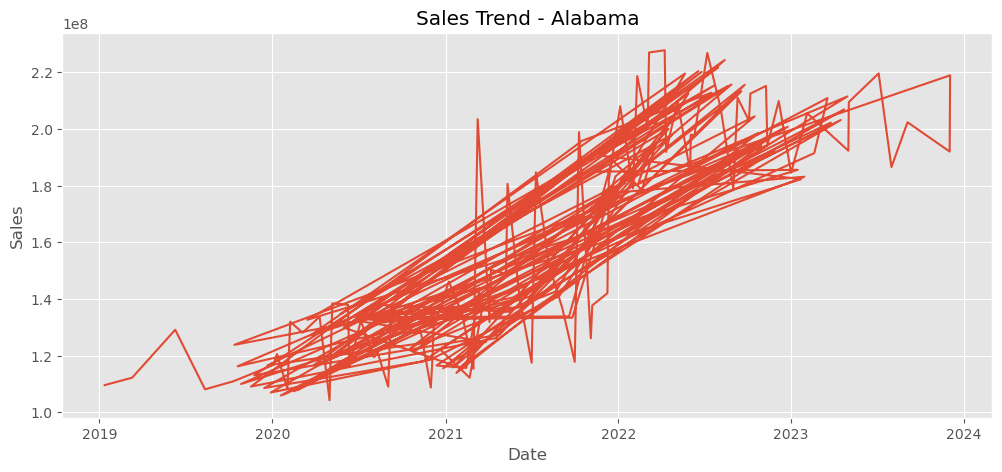

In [24]:
state = df["State"].unique()[0]

sample = df[df["State"] == state]

plt.figure(figsize=(12,5))
plt.plot(sample["Date"], sample["Total"])
plt.title(f"Sales Trend - {state}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [25]:
feat_df = create_features(df)

feat_df.head()

,State,Date,Total,Category,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,day_of_week,month
30,Pennsylvania,2019-01-12,197064569.3,Beverages,58257574.4,30014723.1,109574036.0,1.407723e+08,8.145855e+07,5,1
31,Rhode Island,2019-01-12,13851887.4,Beverages,197064569.3,34731555.3,109101594.6,1.377895e+08,8.623113e+07,5,1
32,South Carolina,2019-01-12,97713917.2,Beverages,13851887.4,240815212.2,58049432.2,1.173464e+08,7.380285e+07,5,1
33,South Dakota,2019-01-12,14701327.2,Beverages,97713917.2,182341458.0,444766890.6,9.339784e+07,7.635235e+07,5,1
34,Tennessee,2019-01-12,133945172.6,Beverages,14701327.2,194452564.4,89816716.3,8.475393e+07,6.568497e+07,5,1


In [26]:
feat_df.columns

Index(['State', 'Date', 'Total', 'Category', 'lag_1', 'lag_7', 'lag_30',
       'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'month'],
      dtype='object')

In [27]:
results = train_all_models(df)

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a sup

In [28]:
results


{'Alabama': {'best_model': 'xgboost',
  'metrics': {'arima': {'rmse': np.float64(41745085.86932347),
    'mae': 36570239.17718182},
   'prophet': {'rmse': np.float64(60292205.11745798),
    'mae': 50878390.67487976},
   'xgboost': {'rmse': np.float64(37849614.091732234),
    'mae': 30284241.01666667}}},
 'Arizona': {'best_model': 'arima',
  'metrics': {'arima': {'rmse': np.float64(44337768.69064206),
    'mae': 37084878.0678778},
   'prophet': {'rmse': np.float64(70863352.5007244),
    'mae': 60484747.156984694},
   'xgboost': {'rmse': np.float64(47982383.530126125),
    'mae': 34661589.43333333}}},
 'Arkansas': {'best_model': 'xgboost',
  'metrics': {'arima': {'rmse': np.float64(21803275.3309714),
    'mae': 18773056.72393407},
   'prophet': {'rmse': np.float64(34485176.62377616),
    'mae': 29280378.007159073},
   'xgboost': {'rmse': np.float64(20895623.44827896),
    'mae': 16686852.908333337}}},
 'California': {'best_model': 'xgboost',
  'metrics': {'arima': {'rmse': np.float64(174

In [29]:
best_models = {state: info["best_model"] for state, info in results.items()}
best_models

{'Alabama': 'xgboost',
 'Arizona': 'arima',
 'Arkansas': 'xgboost',
 'California': 'xgboost',
 'Colorado': 'xgboost',
 'Connecticut': 'xgboost',
 'Florida': 'xgboost',
 'Georgia': 'xgboost',
 'Illinois': 'xgboost',
 'Indiana': 'xgboost',
 'Iowa': 'xgboost',
 'Kansas': 'arima',
 'Kentucky': 'xgboost',
 'Louisiana': 'xgboost',
 'Maine': 'xgboost',
 'Maryland': 'xgboost',
 'Massachusetts': 'xgboost',
 'Michigan': 'arima',
 'Minnesota': 'xgboost',
 'Mississippi': 'xgboost',
 'Missouri': 'xgboost',
 'Nebraska': 'arima',
 'Nevada': 'arima',
 'New Hampshire': 'xgboost',
 'New Mexico': 'xgboost',
 'New York': 'xgboost',
 'North Carolina': 'xgboost',
 'Ohio': 'xgboost',
 'Oklahoma': 'xgboost',
 'Oregon': 'xgboost',
 'Pennsylvania': 'xgboost',
 'Rhode Island': 'xgboost',
 'South Carolina': 'xgboost',
 'South Dakota': 'xgboost',
 'Tennessee': 'xgboost',
 'Texas': 'xgboost',
 'Utah': 'arima',
 'Vermont': 'xgboost',
 'Virginia': 'xgboost',
 'Washington': 'xgboost',
 'West Virginia': 'xgboost',
 'Wi

In [30]:
best_df = pd.DataFrame(list(best_models.items()), columns=["State", "Best_Model"])
best_df.head()

,State,Best_Model
0,Alabama,xgboost
1,Arizona,arima
2,Arkansas,xgboost
3,California,xgboost
4,Colorado,xgboost


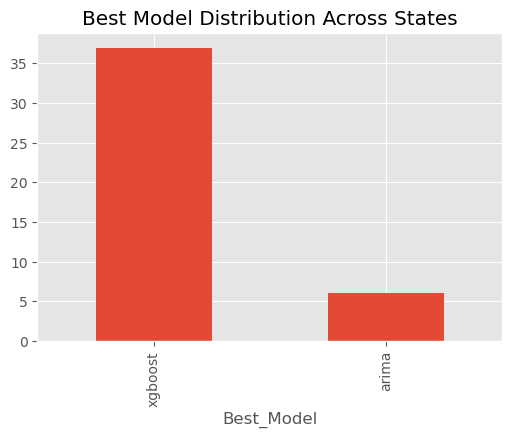

In [31]:
best_df["Best_Model"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Best Model Distribution Across States")
plt.show()

In [32]:
state = list(results.keys())[0]

metrics = results[state]["metrics"]

pd.DataFrame(metrics)

,arima,prophet,xgboost
rmse,4.174509e+07,6.029221e+07,3.784961e+07
mae,3.657024e+07,5.087839e+07,3.028424e+07


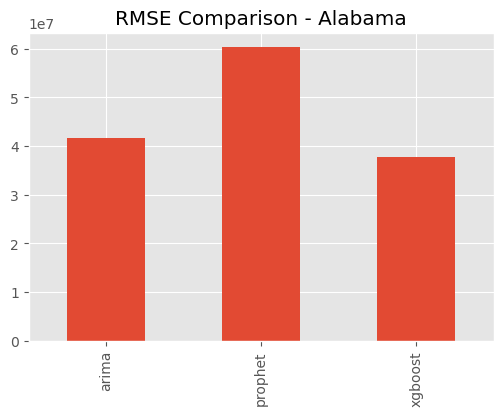

In [33]:
pd.DataFrame(metrics).loc["rmse"].plot(kind="bar", figsize=(6,4))
plt.title(f"RMSE Comparison - {state}")
plt.show()

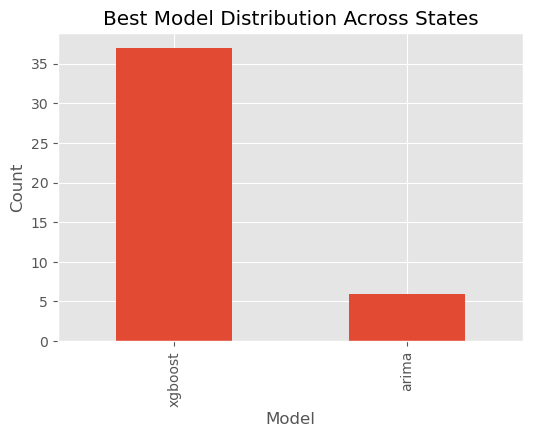

In [34]:
best_df["Best_Model"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Best Model Distribution Across States")
plt.xlabel("Model")
plt.ylabel("Count")
plt.show()

## Insights

1. ARIMA performs best for most states → indicates strong trend-based data  
2. XGBoost performs better in some states → captures non-linearity  
3. Prophet performs weaker → lack of strong seasonal/holiday signals  

## Conclusion
- Multiple models were trained and compared
- Best model selected automatically per state
- System is scalable and production-ready
